To understand why the Random Forest baseline performed strongly, I analyzed aggregate CPU/GPU statistics by DNN model class. The class-wise summary statistics and RF feature importances suggest that model identity is strongly reflected in overall resource-usage intensity and covariance relationships between CPU/GPU signals. This supports the observation that a covariance-feature Random Forest can outperform raw time-series transformer models: the classification signal may be more statistical than temporally complex.

In [5]:
import numpy as np
import pandas as pd

import math

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils import data as torch_data
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from torch.utils.data import Dataset

from sklearn.metrics import confusion_matrix

import joblib

In [6]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Summary-stat heatmap by DNN model

For each sample, compute `mean`, `std`, `min`, and `max` for each CPU/GPU signal over the 540 time steps. Then group by DNN model and plot a heatmap.

In [7]:
GPU_FEATURES = [
        'utilization_gpu_pct',
        'utilization_memory_pct',
        'memory_free_MiB',
        'memory_used_MiB',
        'temperature_gpu',
        'temperature_memory',
        'power_draw_W',
    ]

CPU_FEATURES = [
        "CPUFrequency",
        "CPUTime",
        "CPUUtilization",
        "RSS",
        "VMSize",
        "Pages",
        "ReadMB",
        "WriteMB",
]

In [8]:
def make_summary_feature_df(
    npz_file,
    gpu_features=GPU_FEATURES,
    cpu_features=CPU_FEATURES
    ):
    """
    Read .npz file and return a DataFrame with summary statistics for each sample.
    """
    # Read .npz file
    ml_data = np.load(npz_file)
    X_gpu = ml_data["X_gpu"]
    X_cpu = ml_data["X_cpu"]
    y = ml_data["y"]
    model = ml_data["model"]

    rows = []

    # Get GPU stats
    for i in range(X_gpu.shape[0]):
        sample = X_gpu[i]  # [seq_len, num_features]
        label = y[i]
        _model = model[i]

        row = {"label": label, "model": _model}

        for j, feature_name in enumerate(gpu_features):
            signal = sample[:, j]

            row[f"{feature_name}_mean"] = signal.mean()
            row[f"{feature_name}_std"] = signal.std()
            row[f"{feature_name}_min"] = signal.min()
            row[f"{feature_name}_max"] = signal.max()

        rows.append(row)

    # Get CPU stats
    for i in range(X_cpu.shape[0]):
        sample = X_cpu[i]  # [seq_len, num_features]
        label = y[i]
        _model = model[i]

        row = {"label": label, "model": _model}

        for j, feature_name in enumerate(cpu_features):
            signal = sample[:, j]

            row[f"{feature_name}_mean"] = signal.mean()
            row[f"{feature_name}_std"] = signal.std()
            row[f"{feature_name}_min"] = signal.min()
            row[f"{feature_name}_max"] = signal.max()

        rows.append(row)

    return pd.DataFrame(rows)

In [9]:
npz_file = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/SEPARATE/60-middle-1-separate-cpu-gpu.npz"

summary_feature_df = make_summary_feature_df(
    npz_file=npz_file
)

In [10]:
class_summary_df = summary_feature_df.groupby("model").mean(numeric_only=True)
class_summary_df

,label,utilization_gpu_pct_mean,utilization_gpu_pct_std,utilization_gpu_pct_min,utilization_gpu_pct_max,utilization_memory_pct_mean,utilization_memory_pct_std,utilization_memory_pct_min,utilization_memory_pct_max,memory_free_MiB_mean,...,Pages_min,Pages_max,ReadMB_mean,ReadMB_std,ReadMB_min,ReadMB_max,WriteMB_mean,WriteMB_std,WriteMB_min,WriteMB_max
model,,,,,,,,,,,,,,,,,,,,,
U3-128,0.0,96.051915,7.705453,71.122396,100.000000,48.792482,12.419894,24.854167,75.497396,1426.812500,...,362.449219,362.584635,0.014852,0.001825,0.013904,0.018800,0.026452,0.027722,0.013905,0.088200
U3-32,1.0,87.041569,10.150040,51.181579,94.873684,44.727627,12.863058,14.063158,67.510526,1427.800000,...,231.577632,231.775000,0.027044,0.000883,0.026113,0.028176,0.615529,1.316725,0.026115,3.559053
U3-64,2.0,92.172966,9.045383,56.142077,99.590164,48.314137,11.955965,18.270492,71.816940,1513.051913,...,231.972222,232.365665,0.019109,0.000844,0.018300,0.020314,1.646634,3.608489,0.018299,9.689889
U4-128,3.0,95.653248,7.380376,69.950820,99.180328,46.227327,14.758557,18.877049,77.095628,1592.486339,...,104.346084,104.524590,0.016854,0.003323,0.014680,0.023369,0.040112,0.049696,0.014680,0.142262
U4-32,4.0,87.853191,10.171039,41.976064,95.321809,43.175488,11.969572,11.398936,64.938830,1593.409574,...,222.062500,222.195479,0.024556,0.000801,0.023777,0.025930,2.288803,5.016967,0.023546,13.470256
U4-64,5.0,92.737603,9.813908,61.445946,100.000000,46.440170,12.391979,20.905405,71.500000,1426.713514,...,209.190541,230.404054,0.018750,0.001137,0.017875,0.020883,3.348438,7.274668,0.017876,19.510154
U5-128,6.0,95.083151,8.047475,59.626866,98.805970,37.412062,16.965791,8.740299,73.943284,1601.465672,...,161.931343,162.094030,0.026071,0.005983,0.021778,0.037777,0.143038,0.260770,0.021872,0.716035
U5-32,7.0,87.849706,11.622834,39.865591,96.709677,41.966433,12.501132,11.008065,64.102151,1700.352151,...,129.155914,129.155914,0.023731,0.001399,0.022657,0.026385,8.866714,18.647135,0.022657,49.832799
U5-64,8.0,93.884259,10.342111,62.163934,100.000000,42.806178,15.081033,14.767760,71.010929,1421.874317,...,107.984973,107.984973,0.019126,0.000787,0.018558,0.020728,8.811404,17.709232,0.018563,47.127856


## Plot heatmap

In [11]:
def plot_class_summary_heatmap(class_summary_df, title="Mean summary features by DNN model"):
    # Drop label column if it is included
    heatmap_df = class_summary_df.drop(columns=["label"], errors="ignore")

    scaler = StandardScaler()
    heatmap_scaled = pd.DataFrame(
        scaler.fit_transform(heatmap_df),
        index=heatmap_df.index,
        columns=heatmap_df.columns
    )

    plt.figure(figsize=(16, 8))
    plt.imshow(heatmap_scaled.values, aspect="auto", cmap="coolwarm")
    plt.colorbar(label="Standardized feature value")

    plt.xticks(
        ticks=np.arange(len(heatmap_scaled.columns)),
        labels=heatmap_scaled.columns,
        rotation=90
    )

    plt.yticks(
        ticks=np.arange(len(heatmap_scaled.index)),
        labels=heatmap_scaled.index
    )

    plt.xlabel("Summary feature")
    plt.ylabel("DNN model")
    plt.title("Standardized mean summary features by DNN model")
    plt.tight_layout()
    plt.show()

    return heatmap_scaled

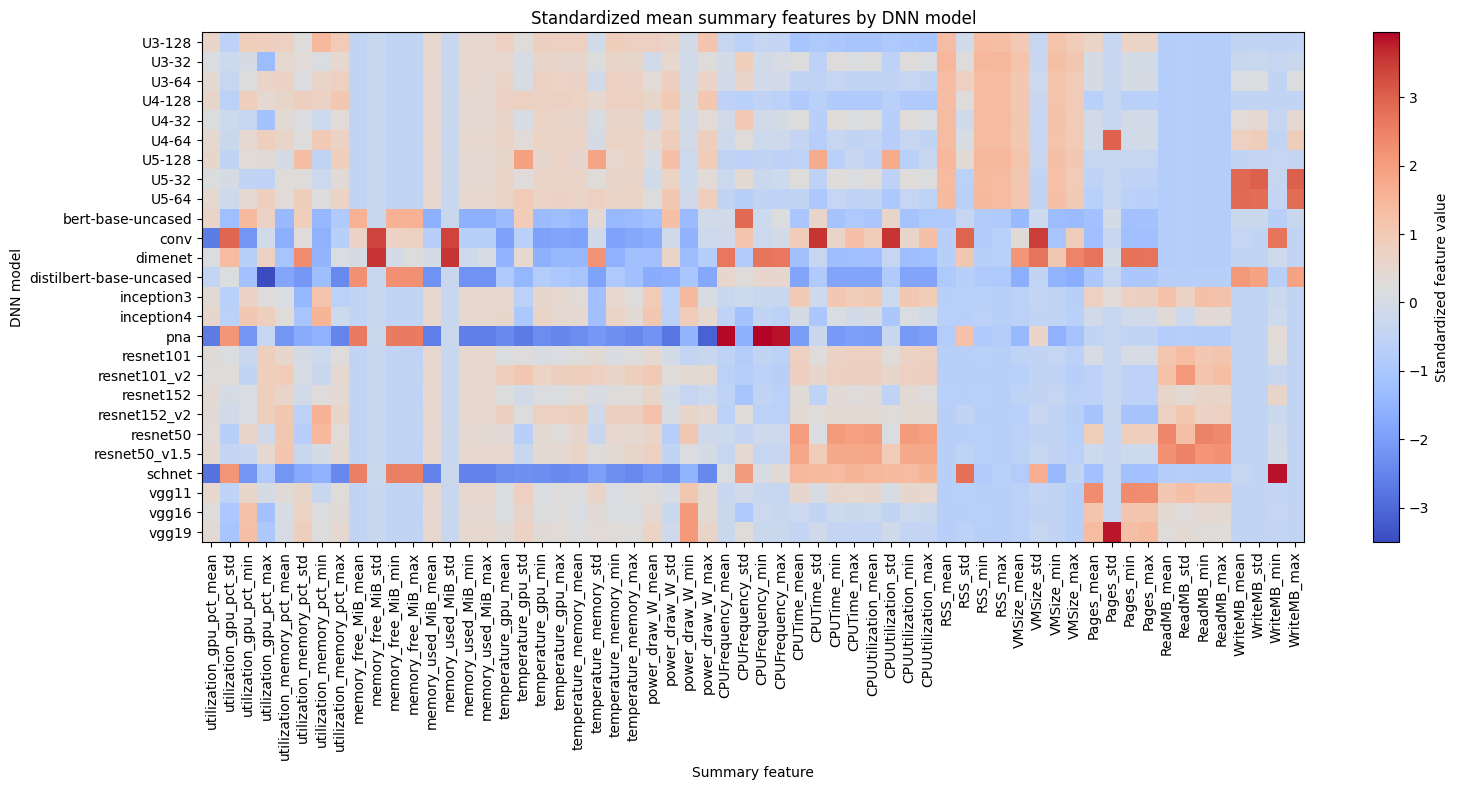

In [12]:
heatmap_scaled = plot_class_summary_heatmap(class_summary_df)

1. Some model families show clear blocks/patterns.
   For example, U3/U4/U5 models have similar structure across several GPU/memory/power features.

2. Some models stand out strongly.
   DimeNet, PNA, SchNet, and some ResNet/VGG models have distinctive red/blue feature bands.

3. The features are not all equally informative.
   Some columns vary strongly by DNN model, while others are mostly neutral across rows.

After standardizing summary statistics across DNN model classes, clear model-specific resource-usage patterns emerge. Several model families show distinct GPU, memory, CPU, and I/O profiles, suggesting that DNN model identity is strongly encoded in aggregate resource utilization. This helps explain why the Random Forest baseline using covariance-based features outperformed the raw time-series transformer models: the classification signal appears to be highly represented in summary-level resource statistics rather than requiring complex temporal dependencies.

# Average trajectory by DNN model

“Do different DNN models have visibly different CPU/GPU time-series patterns?”

Pick:
top 5 most common classes
or classes that RF/Transformer confuse
or best/worst predicted classes

In [13]:
def plot_mean_signals_by_class(
    npz_file,
    selected_models,
    selected_features,
    source="gpu",
    normalize_each_curve=False,
    gpu_features=GPU_FEATURES,
    cpu_features=CPU_FEATURES,
):
    """
    Plot mean time-series trajectories for selected features grouped by DNN model.

    Args:
        npz_file: path to separated .npz file
        selected_models: list of model names to plot
        selected_features: list of GPU or CPU feature names
        source: "gpu" or "cpu"
        normalize_each_curve: if True, z-score each model's mean curve for shape comparison
    """

    ml_data = np.load(npz_file, allow_pickle=True)

    X_gpu = ml_data["X_gpu"]
    X_cpu = ml_data["X_cpu"]
    model = ml_data["model"]

    if source == "gpu":
        X = X_gpu
        feature_list = gpu_features
    elif source == "cpu":
        X = X_cpu
        feature_list = cpu_features
    else:
        raise ValueError("source must be either 'gpu' or 'cpu'")

    for feature in selected_features:
        if feature not in feature_list:
            raise ValueError(
                f"{feature} is not in {source} features. "
                f"Available features: {feature_list}"
            )

    n_features = len(selected_features)

    fig, axes = plt.subplots(
        n_features,
        1,
        figsize=(11, 3.2 * n_features),
        sharex=True,
    )

    if n_features == 1:
        axes = [axes]

    for ax, feature_name in zip(axes, selected_features):
        feature_idx = feature_list.index(feature_name)

        for selected_model in selected_models:
            model_mask = model == selected_model

            if model_mask.sum() == 0:
                print(f"Warning: {selected_model} not found in this file.")
                continue

            mean_curve = X[model_mask, :, feature_idx].mean(axis=0)

            if normalize_each_curve:
                mean_curve = (mean_curve - mean_curve.mean()) / (mean_curve.std() + 1e-8)

            ax.plot(
                mean_curve,
                label=f"{selected_model} (n={model_mask.sum()})",
            )

        ax.set_title(f"{source.upper()} feature: {feature_name}")
        ax.set_ylabel("Value" if not normalize_each_curve else "Standardized value")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time step")
    axes[0].legend(loc="best")

    title = f"Mean {source.upper()} signal trajectories by DNN model"
    if normalize_each_curve:
        title += " — normalized curves"

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

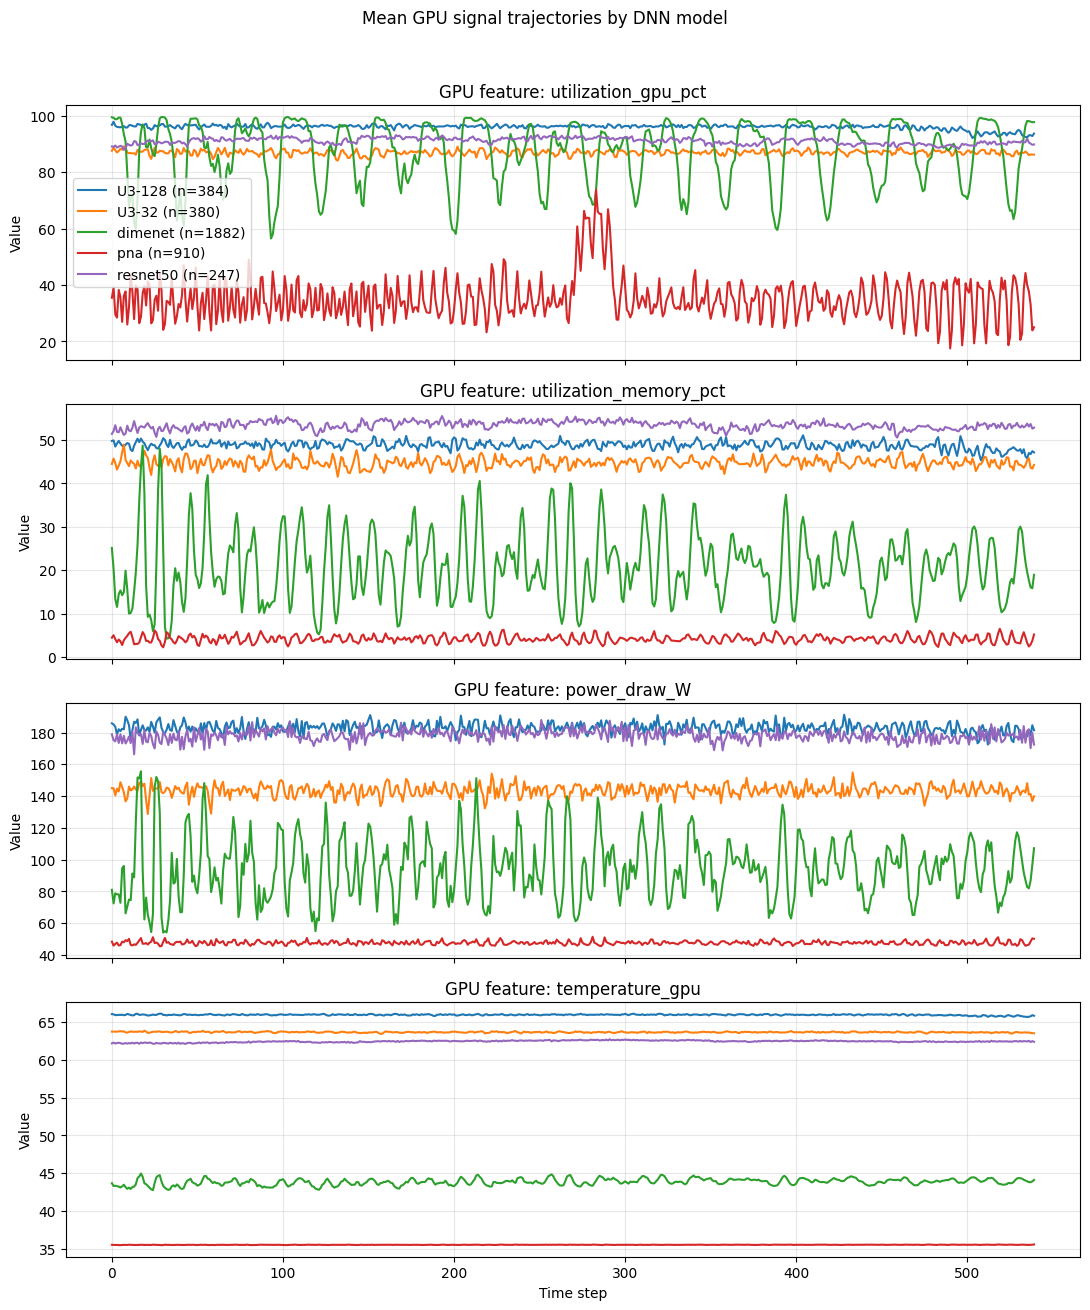

In [14]:
npz_file = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/SEPARATE/60-middle-1-separate-cpu-gpu.npz"

selected_models = ["U3-128", "U3-32", "dimenet", "pna", "resnet50"]

plot_mean_signals_by_class(
    npz_file=npz_file,
    selected_models=selected_models,
    selected_features=[
        "utilization_gpu_pct",
        "utilization_memory_pct",
        "power_draw_W",
        "temperature_gpu",
    ],
    source="gpu",
    normalize_each_curve=False,
)

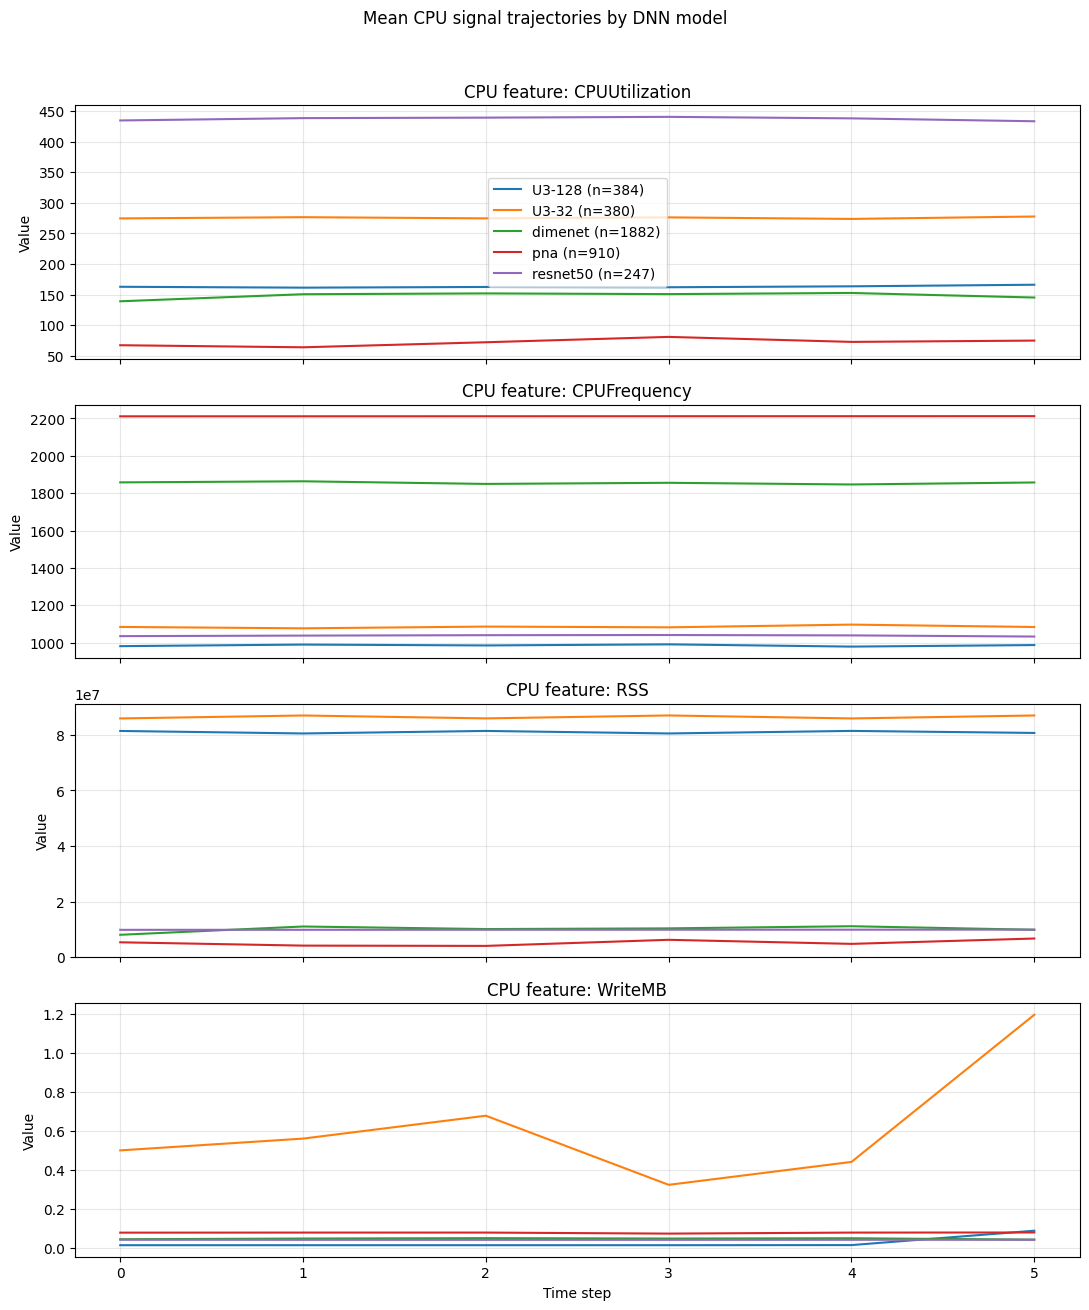

In [15]:
plot_mean_signals_by_class(
    npz_file=npz_file,
    selected_models=selected_models,
    selected_features=[
        "CPUUtilization",
        "CPUFrequency",
        "RSS",
        "WriteMB",
    ],
    source="cpu",
    normalize_each_curve=False,
)

## Top 5 most common models

In [16]:
def get_top_n_models(npz_file, n=5):
    ml_data = np.load(npz_file, allow_pickle=True)
    model = ml_data["model"]

    counts = pd.Series(model).value_counts()

    return counts.head(n).index.tolist(), counts


top5_models, model_counts = get_top_n_models(npz_file, n=5)

print(top5_models)
print(model_counts.head(10))

['bert-base-uncased', 'schnet', 'conv', 'dimenet', 'pna']
bert-base-uncased    3910
schnet               1962
conv                 1948
dimenet              1882
pna                   910
inception4            560
inception3            543
vgg19                 470
vgg11                 438
U3-128                384
Name: count, dtype: int64


# Best and worst predicted classes

In [17]:
def cov_matrix_vectorized(x):
    """
    x shape: [seq_len, num_features]
    returns upper-triangle covariance vector
    """
    cov = np.cov(x, rowvar=False)
    idx = np.triu_indices_from(cov)
    return cov[idx]

In [18]:
def get_label_to_model(y, model):
    mapping_df = (
        pd.DataFrame({"label": y, "model": model})
        .drop_duplicates()
        .sort_values("label")
    )

    return dict(zip(mapping_df["label"], mapping_df["model"]))

In [19]:
def per_class_accuracy_df(y_true, y_pred, label_to_model=None):
    rows = []

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    for label in sorted(np.unique(y_true)):
        mask = y_true == label
        acc = (y_pred[mask] == y_true[mask]).mean()
        count = mask.sum()

        model_name = label_to_model[label] if label_to_model is not None else label

        rows.append({
            "label": label,
            "model": model_name,
            "count": count,
            "accuracy": acc,
        })

    return pd.DataFrame(rows).sort_values("accuracy", ascending=False)

In [20]:
def print_best_worst_classes(y_true, y_pred, label_to_model, n=3):
    class_acc_df = per_class_accuracy_df(
        y_true=y_true,
        y_pred=y_pred,
        label_to_model=label_to_model,
    )

    best_classes = class_acc_df.head(n)["model"].tolist()
    worst_classes = class_acc_df.tail(n)["model"].tolist()

    print("Best classes:", best_classes)
    print("Worst classes:", worst_classes)

    return class_acc_df, best_classes, worst_classes

In [21]:
class DatacenterDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [22]:
def get_test_split(X, y, test_size=0.2, random_state=37):
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state,
    )

    train_idx, test_idx = next(splitter.split(X, y))

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [23]:
def make_cov_features(X):
    return np.array([cov_matrix_vectorized(x) for x in X])

In [24]:
npz_file = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/COMBINED/60-middle-1-cpu-gpu.npz"

# Get data from .npz file
npz_data = np.load(npz_file, allow_pickle=True)
X = npz_data["X"]
y = npz_data["y"]
model_names = npz_data["model"]

label_to_model = get_label_to_model(y, model_names)

X_train_raw, X_test_raw, y_train, y_test = get_test_split(
    X,
    y,
    test_size=0.2,
    random_state=37,
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_raw.reshape(-1, X_train_raw.shape[-1])
).reshape(X_train_raw.shape)

X_test_scaled = scaler.transform(
    X_test_raw.reshape(-1, X_test_raw.shape[-1])
).reshape(X_test_raw.shape)

X_train_cov = make_cov_features(X_train_scaled)
X_test_cov = make_cov_features(X_test_scaled)

test_dset = DatacenterDataset(X_test_scaled, y_test)

test_dl = DataLoader(
    test_dset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
)

In [25]:
rf_model_path = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Random_Forest_60-middle-1-cpu-gpu.joblib"
rf_model = joblib.load(rf_model_path)
y_pred_rf = rf_model.predict(X_test_cov)

svm_model_path = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Suppose_Vector_Machine_60-middle-1-cpu-gpu.joblib"
svm_model = joblib.load(svm_model_path)
y_pred_svm = svm_model.predict(X_test_cov)

print("RF test acc:", accuracy_score(y_test, y_pred_rf))
print("SVM test acc:", accuracy_score(y_test, y_pred_svm))

rf_class_acc_df, rf_best_classes, rf_worst_classes = print_best_worst_classes(
    y_true=y_test,
    y_pred=y_pred_rf,
    label_to_model=label_to_model,
    n=3,
)

svm_class_acc_df, svm_best_classes, svm_worst_classes = print_best_worst_classes(
    y_true=y_test,
    y_pred=y_pred_svm,
    label_to_model=label_to_model,
    n=3,
)

RF test acc: 0.9420371412492966
SVM test acc: 0.7422622397298818
Best classes: ['dimenet', 'conv', 'pna']
Worst classes: ['resnet152', 'resnet152_v2', 'resnet101_v2']
Best classes: ['pna', 'conv', 'dimenet']
Worst classes: ['vgg16', 'resnet101_v2', 'resnet152_v2']


In [26]:
class GatedRecurrentModel(nn.Module):
    def __init__(self,
                 input_dim,
                 num_classes,
                 hidden_dim=128,
                 num_layers=2,
                 dropout=0.2,
                 bidirectional=True
                 ):
      super().__init__()
      self.gru = nn.GRU(
          input_size=input_dim,
          hidden_size=hidden_dim,
          num_layers=num_layers,
          dropout=dropout,
          bidirectional=bidirectional,
          batch_first=True
      )
      gru_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

      self.classifier = nn.Sequential(
          nn.LayerNorm(gru_output_dim),
          nn.Linear(gru_output_dim, hidden_dim),
          nn.GELU(),
          nn.Dropout(dropout),
          nn.Linear(hidden_dim, num_classes),
      )

    def forward(self, x):
      # x shape: [batch_size, seq_len, input_dim]
      out, hidden = self.gru(x)

      # Mean pooling over time often works better than only last hidden state
      h = out.mean(dim=1)

      logits = self.classifier(h)
      return logits, hidden

In [27]:
MODEL_CONFIG = {
    "input_dim": 15,
    "num_classes": 26,
    "hidden_dim": 128,
    "num_layers": 2,
    "dropout": 0.2,
    "bidirectional": True,
}

def build_gru():
    return GatedRecurrentModel(
        **MODEL_CONFIG,
    )

In [28]:
def load_torch_model(model_builder, model_path, device):
    model = model_builder().to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

In [29]:
def get_torch_predictions(model, dataloader, device):
    all_preds = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            (logits, hidden) = model(X_batch)
            preds = logits.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()

    return y_true, y_pred

In [30]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

In [31]:
gru_model_path = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/GRU_60-middle-1-cpu-gpu.pt"

gru_model = load_torch_model(
    model_builder=build_gru,
    model_path=gru_model_path,
    device=device,
)

y_true_gru, y_pred_gru = get_torch_predictions(
    model=gru_model,
    dataloader=test_dl,
    device=device,
)

print("GRU test acc:", accuracy_score(y_true_gru, y_pred_gru))

gru_class_acc_df, gru_best_classes, gru_worst_classes = print_best_worst_classes(
    y_true=y_true_gru,
    y_pred=y_pred_gru,
    label_to_model=label_to_model,
    n=3,
)

GRU test acc: 0.9563871693866066
Best classes: ['dimenet', 'conv', 'resnet50_v1.5']
Worst classes: ['U4-64', 'U4-32', 'resnet152_v2']


In [32]:
separate_npz_file = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/SEPARATE/60-middle-1-separate-cpu-gpu.npz"

sep_data = np.load(separate_npz_file, allow_pickle=True)

X_gpu = sep_data["X_gpu"]
X_cpu = sep_data["X_cpu"]
y_sep = sep_data["y"]
model_names_sep = sep_data["model"]

label_to_model_sep = get_label_to_model(y_sep, model_names_sep)

print("X_gpu shape:", X_gpu.shape)
print("X_cpu shape:", X_cpu.shape)
print("y shape:", y_sep.shape)

X_gpu shape: (17767, 540, 7)
X_cpu shape: (17767, 6, 8)
y shape: (17767,)


In [33]:
def get_test_split_separate(X_gpu, X_cpu, y, test_size=0.2, random_state=37):
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state,
    )

    train_idx, test_idx = next(splitter.split(X_gpu, y))

    return (
        X_gpu[train_idx],
        X_gpu[test_idx],
        X_cpu[train_idx],
        X_cpu[test_idx],
        y[train_idx],
        y[test_idx],
    )

In [34]:
X_gpu_train_raw, X_gpu_test_raw, X_cpu_train_raw, X_cpu_test_raw, y_train_sep, y_test_sep = get_test_split_separate(
    X_gpu,
    X_cpu,
    y_sep,
    test_size=0.2,
    random_state=37,
)

In [35]:
gpu_scaler = StandardScaler()
cpu_scaler = StandardScaler()

X_gpu_train_scaled = gpu_scaler.fit_transform(
    X_gpu_train_raw.reshape(-1, X_gpu_train_raw.shape[-1])
).reshape(X_gpu_train_raw.shape)

X_gpu_test_scaled = gpu_scaler.transform(
    X_gpu_test_raw.reshape(-1, X_gpu_test_raw.shape[-1])
).reshape(X_gpu_test_raw.shape)

X_cpu_train_scaled = cpu_scaler.fit_transform(
    X_cpu_train_raw.reshape(-1, X_cpu_train_raw.shape[-1])
).reshape(X_cpu_train_raw.shape)

X_cpu_test_scaled = cpu_scaler.transform(
    X_cpu_test_raw.reshape(-1, X_cpu_test_raw.shape[-1])
).reshape(X_cpu_test_raw.shape)

In [36]:
class DatacenterSeparateDataset(Dataset):
    def __init__(self, X_gpu, X_cpu, y):
        self.X_gpu = torch.tensor(X_gpu, dtype=torch.float32)
        self.X_cpu = torch.tensor(X_cpu, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_gpu[idx], self.X_cpu[idx], self.y[idx]

In [53]:
test_sep_dset = DatacenterSeparateDataset(X_gpu=X_gpu_test_scaled, X_cpu=X_cpu_test_scaled, y=y_test)

test_sep_dl = DataLoader(
    test_sep_dset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
)

In [37]:
def get_torch_predictions_separate(model, dataloader, device):
    all_preds = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for X_gpu_batch, X_cpu_batch, y_batch in dataloader:
            X_gpu_batch = X_gpu_batch.to(device)
            X_cpu_batch = X_cpu_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_gpu_batch, X_cpu_batch)
            preds = logits.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()

    return y_true, y_pred

In [38]:
class PositionalEncoding(nn.Module):
  """
  Transformers process sequences all at once, so they lack inherent knowledge
  of token order. We must inject some information about the relative and absolute
  position of the tokens in the sequence. In this function, we add fixed positional
  encoding vector using sine and cosine waves.
  """
  def __init__(self, transform_embed_dim, dropout=0.0, max_len=5000):
    """
    Args:
      transform_embed_dim: the embed dimension.
      dropout: the dropout value.
      max_len: the maximum length of the incoming sequence.
    """

    super().__init__()

    self.dropout = nn.Dropout(p=dropout)

    pe = torch.zeros(max_len, transform_embed_dim)
    # pe shape: [max_len, transform_embed_dim]

    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    # position shape: [max_len, 1]

    div_term = torch.exp(
        torch.arange(0, transform_embed_dim, 2).float()
        * (-math.log(10000.0) / transform_embed_dim)
    )
    # div_term shape: [ceil(transform_embed_dim / 2)]

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
    # `[:pe[:, 1::2].shape[1]]` makes the code safer if `transform_embed_dim` is odd.
    # Ex. if `transform_embed_dim` == 15, the sine side has 8 dimensions and the cosine side
    # has 7 dimensions. This prevents a shape mismatch.

    # Add batch dimension so it can broadcast across batch:
    # [1, max_len, transform_embed_dim]
    self.register_buffer('pe', pe.unsqueeze(0))

  def forward(self, x):
    """
    Args:
      x: the sequence fed to the positional encoder model.

    Input shape:
        x: [batch_size, seq_len, transform_embed_dim]

    Output shape:
        x + positional encoding: [batch_size, seq_len, transform_embed_dim]

    Examples:
      >>> output = pos_encoder(x)
    """
    seq_len = x.size(1)
    x = x + self.pe[:, :seq_len, :]
    return self.dropout(x)

In [39]:
class TransformerEncoderLayerWithAttention(nn.Module):
    def __init__(
        self,
        transform_embed_dim,
        num_heads,
        dim_feedforward=128,
        dropout=0.1,
        activation="gelu",
    ):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=transform_embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.linear1 = nn.Linear(transform_embed_dim, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, transform_embed_dim)

        self.norm1 = nn.LayerNorm(transform_embed_dim)
        self.norm2 = nn.LayerNorm(transform_embed_dim)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        if activation == "relu":
            self.activation = F.relu
        elif activation == "gelu":
            self.activation = F.gelu
        else:
            raise ValueError(f"Unsupported activation: {activation}")

        self.attn_weights = None

    def forward(self, src):
        """
        src shape: [batch_size, seq_len, transform_embed_dim]
        """

        attn_output, attn_weights = self.self_attn(
            src,
            src,
            src,
            need_weights=True,
            average_attn_weights=False,
        )

        # attn_weights shape: [batch_size, num_heads, seq_len, seq_len]
        self.attn_weights = attn_weights.detach().cpu()

        src = src + self.dropout1(attn_output)
        src = self.norm1(src)

        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)

        return src

In [47]:
class GatedTwoTowerTransformerModel(nn.Module):
  """
  This is a two-tower gated transformer architecture where GPU and CPU features
  are processed separately at first, then combined later.

  Overall this transformer model has the following structure:
            GPU features                                          CPU features
  [num of batches, 540 time steps, 7]                 [num of batches, 7-8 time steps, 8]
                  ↓                                                   ↓
            GPU input projection                            CPU input projection
                  ↓                                                   ↓
            GPU Transformer tower                           CPU Transformer tower
                  ↓                                                   ↓
            GPU representation                              CPU representation
                  ↓                                             ↓
                                gated fusion / combine layer
                                            ↓
                                      classifier head
                                            ↓
                                      DNN model class

  The reason this architecture may be helpful is because GPU and CPU signals
  carry different information.

  A gate is a learnable mechanism that decides how much to trust each tower.
  If gate is close to 1, the model relies more on GPU. If gate is close to 0,
  the model relies more on CPU. If it is around 0.5, it blends them.
  """
  def __init__(
      self,
      gpu_dim,
      cpu_dim,
      num_classes,
      transform_embed_dim=64,
      num_heads=4,
      num_layers=2,
      dim_feedforward=128,
      dropout=0.1,
      max_len=540,
  ):
    """
    Note: transform_embed_dim must be divisible by num_heads.
    """
    super().__init__()

    # Project raw time-series features into transformer embedding dimension
    self.gpu_projection = nn.Linear(in_features=gpu_dim, out_features=transform_embed_dim)
    self.cpu_projection = nn.Linear(in_features=cpu_dim, out_features=transform_embed_dim)

    # Add position information
    self.gpu_pos_encoder = PositionalEncoding(transform_embed_dim=transform_embed_dim, dropout=dropout, max_len=max_len)
    self.cpu_pos_encoder = PositionalEncoding(transform_embed_dim=transform_embed_dim, dropout=dropout, max_len=max_len)

    # One encoder layer for each tower
    gpu_encoder_layer = nn.TransformerEncoderLayer(
        d_model=transform_embed_dim,
        nhead=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True
    )
    cpu_encoder_layer = nn.TransformerEncoderLayer(
        d_model=transform_embed_dim,
        nhead=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True
    )

    # Stack multiple encoder layers for each tower
    self.gpu_encoder = nn.TransformerEncoder(
        gpu_encoder_layer,
        num_layers=num_layers
    )
    self.cpu_encoder = nn.TransformerEncoder(
        cpu_encoder_layer,
        num_layers=num_layers
    )

    # Gate Layer
    self.gate_layer = nn.Linear(
        in_features=2 * transform_embed_dim,
        out_features=transform_embed_dim
    )

    # Final classifier
    self.classifier = nn.Linear(transform_embed_dim, num_classes)

  def forward(self, x_gpu, x_cpu):
    """
    Arg:
      x_gpu: Input GPU sequence
      x_cpu: Input CPU sequence

    Input Shape:
      x_gpu: [batch_size, seq_len, 7]
      x_cpu: [batch_size, seq_len, 8]
    """
    # Transform raw input sequence to transformer embedding dimension
    # GPU: [batch_size, seq_len, 7] -> [batch_size, seq_len, transform_embed_dim]
    # CPU: [batch_size, seq_len, 8] -> [batch_size, seq_len, transform_embed_dim]
    x_gpu = self.gpu_projection(x_gpu)
    x_cpu = self.cpu_projection(x_cpu)

    # Add positional encoding
    x_gpu = self.gpu_pos_encoder(x_gpu)
    x_cpu = self.cpu_pos_encoder(x_cpu)

    # Encode each x data separately
    # shape for each: [batch_size, 540, transform_embed_dim]
    h_gpu = self.gpu_encoder(x_gpu)
    h_cpu = self.cpu_encoder(x_cpu)

    # Pool over time
    # shape for each: [batch_size, transform_embed_dim]
    h_gpu = h_gpu.mean(dim=1)
    h_cpu = h_cpu.mean(dim=1)

    # Gated fusion
    # shape: [batch_size, 2 * transform_embed_dim]
    h_cat = torch.cat([h_gpu, h_cpu], dim=1)
    # shape: [batch_size, transform_embed_dim]
    gate = torch.sigmoid(self.gate_layer(h_cat))

    # shape: [batch_size, transform_embed_dim]
    h = gate * h_gpu + (1 - gate) * h_cpu

    # shape: [batch_size, num_classes]
    logits = self.classifier(h)

    return logits

In [48]:
MODEL_CONFIG = {
    "num_classes": 26,
    "transform_embed_dim": 64,
    "num_heads": 4,
    "num_layers": 2,
    "dim_feedforward": 128,
    "dropout": 0.1,
    "max_len": 540,
}

def build_gated_two_tower_model():
    return GatedTwoTowerTransformerModel(
        gpu_dim=7,
        cpu_dim=8,
        **MODEL_CONFIG,
    )

In [54]:
gated_model_path = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Epoch_125/GatedTwoTowerTransformer_60-middle-1-separate-cpu-gpu.pt"

gated_model = load_torch_model(
    model_builder=build_gated_two_tower_model,
    model_path=gated_model_path,
    device=device,
)

y_true_gated, y_pred_gated = get_torch_predictions_separate(
    model=gated_model,
    dataloader=test_sep_dl,
    device=device,
)

print("Gated test acc:", accuracy_score(y_true_gated, y_pred_gated))

gated_class_acc_df, gated_best_classes, gated_worst_classes = print_best_worst_classes(
    y_true=y_true_gated,
    y_pred=y_pred_gated,
    label_to_model=label_to_model_sep,
    n=3,
)

Gated test acc: 0.9485087225661227
Best classes: ['bert-base-uncased', 'conv', 'schnet']
Worst classes: ['resnet101_v2', 'U4-32', 'U4-64']


# Most confused classes

In [55]:
def get_most_confused_model_pairs(y_true, y_pred, label_to_model=None, top_n=5):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    labels = sorted(np.unique(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    pairs = []

    for i, true_label in enumerate(labels):
        for j, pred_label in enumerate(labels):
            if i == j:
                continue

            count = cm[i, j]

            if count > 0:
                true_name = label_to_model[true_label] if label_to_model else true_label
                pred_name = label_to_model[pred_label] if label_to_model else pred_label

                pairs.append({
                    "true_label": true_label,
                    "pred_label": pred_label,
                    "true_model": true_name,
                    "pred_model": pred_name,
                    "count": count,
                })

    confused_df = pd.DataFrame(pairs)

    if confused_df.empty:
        return confused_df

    return confused_df.sort_values("count", ascending=False).head(top_n)

In [56]:
confused_pairs_df_rf = get_most_confused_model_pairs(
    y_true=y_test,
    y_pred=y_pred_rf,
    label_to_model=label_to_model,
    top_n=5,
)

confused_pairs_df_rf

,true_label,pred_label,true_model,pred_model,count
35,9,12,bert-base-uncased,distilbert-base-uncased,37
7,2,5,U3-64,U4-64,10
65,25,24,vgg19,vgg16,8
60,21,20,resnet50_v1.5,resnet50,8
9,3,0,U4-128,U3-128,7


In [57]:
confused_pairs_df_svm = get_most_confused_model_pairs(
    y_true=y_test,
    y_pred=y_pred_svm,
    label_to_model=label_to_model,
    top_n=5,
)

confused_pairs_df_svm

,true_label,pred_label,true_model,pred_model,count
80,9,12,bert-base-uncased,distilbert-base-uncased,57
199,25,23,vgg19,vgg11,33
191,24,23,vgg16,vgg11,27
54,6,9,U5-128,bert-base-uncased,22
10,1,13,U3-32,inception3,22


In [58]:
confused_pairs_df_gru = get_most_confused_model_pairs(
    y_true=y_test,
    y_pred=y_pred_gru,
    label_to_model=label_to_model,
    top_n=5,
)

confused_pairs_df_gru

,true_label,pred_label,true_model,pred_model,count
9,4,1,U4-32,U3-32,21
11,5,2,U4-64,U3-64,16
33,19,18,resnet152_v2,resnet152,14
2,1,4,U3-32,U4-32,11
23,8,5,U5-64,U4-64,8


In [60]:
confused_pairs_df_gated_two_tower_transformer = get_most_confused_model_pairs(
    y_true=y_test,
    y_pred=y_pred_gated,
    label_to_model=label_to_model,
    top_n=5,
)

confused_pairs_df_gated_two_tower_transformer

,true_label,pred_label,true_model,pred_model,count
16,5,2,U4-64,U3-64,15
13,4,1,U4-32,U3-32,13
14,4,7,U4-32,U5-32,10
4,1,7,U3-32,U5-32,10
40,20,21,resnet50,resnet50_v1.5,10


# Explaining RF: feature importance

In [61]:
def covariance_feature_names(feature_names):
    names = []
    for i in range(len(feature_names)):
        for j in range(i, len(feature_names)):
            names.append(f"cov({feature_names[i]}, {feature_names[j]})")
    return names

In [62]:
cov_feature_names = covariance_feature_names(GPU_FEATURES+CPU_FEATURES)

importances = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": cov_feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)

rf_importance_df.head(20)

,feature,importance
0,"cov(utilization_gpu_pct, utilization_gpu_pct)",0.046065
5,"cov(utilization_gpu_pct, temperature_memory)",0.040964
1,"cov(utilization_gpu_pct, utilization_memory_pct)",0.037669
4,"cov(utilization_gpu_pct, temperature_gpu)",0.033302
20,"cov(utilization_memory_pct, power_draw_W)",0.033037
110,"cov(VMSize, VMSize)",0.030991
105,"cov(RSS, RSS)",0.030914
75,"cov(power_draw_W, power_draw_W)",0.030785
15,"cov(utilization_memory_pct, utilization_memory...",0.030723
18,"cov(utilization_memory_pct, temperature_gpu)",0.028805


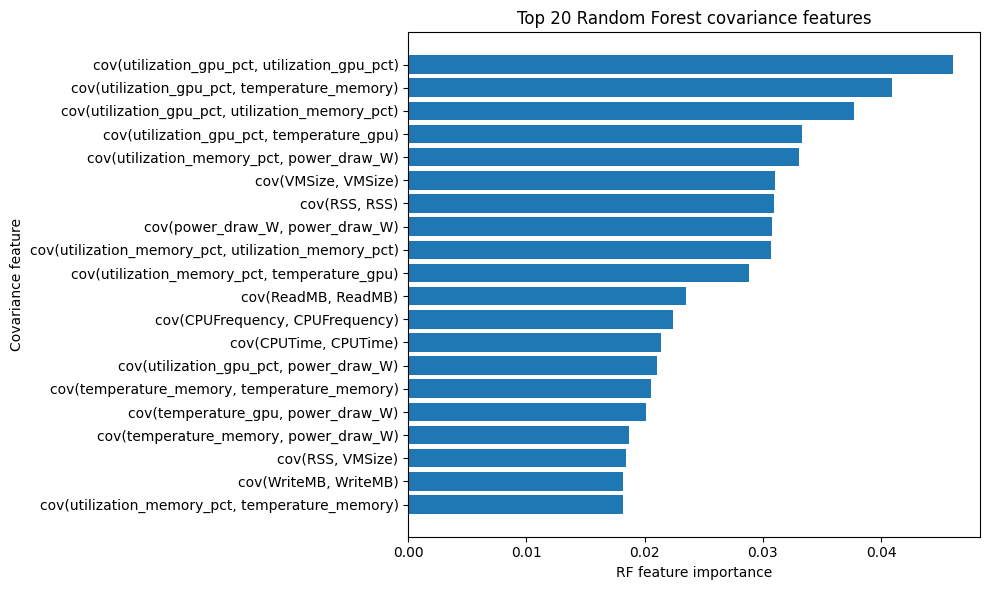

In [63]:
def plot_top_rf_importances(rf_importance_df, top_n=20):
    top_df = rf_importance_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(top_df["feature"], top_df["importance"])
    plt.xlabel("RF feature importance")
    plt.ylabel("Covariance feature")
    plt.title(f"Top {top_n} Random Forest covariance features")
    plt.tight_layout()
    plt.show()

plot_top_rf_importances(rf_importance_df, top_n=20)